In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.widgets import Slider

import numpy as np


In [2]:
class Wave:
    def __init__(self, frequency, phase=0.0):
        self.frequency = frequency
        self.phase = phase

    def value(self, t):
        return np.sin(np.pi * self.frequency * t + self.phase)


class Lissajous:
    def __init__(self, a, b, delta, t=np.linspace(0, 10, 1000)):
        self.a = a
        self.b = b
        self.t = t
        self.delta = delta

        self.wave1 = Wave(a, 0)
        self.wave2 = Wave(b, delta)

    def value(self):
        x = self.wave1.value(self.t)
        y = self.wave2.value(self.t)

        return x, y


def blank_ax(ax):
    # hide spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # hide ticks
    ax.set_xticks([])
    ax.set_yticks([])

    return ax

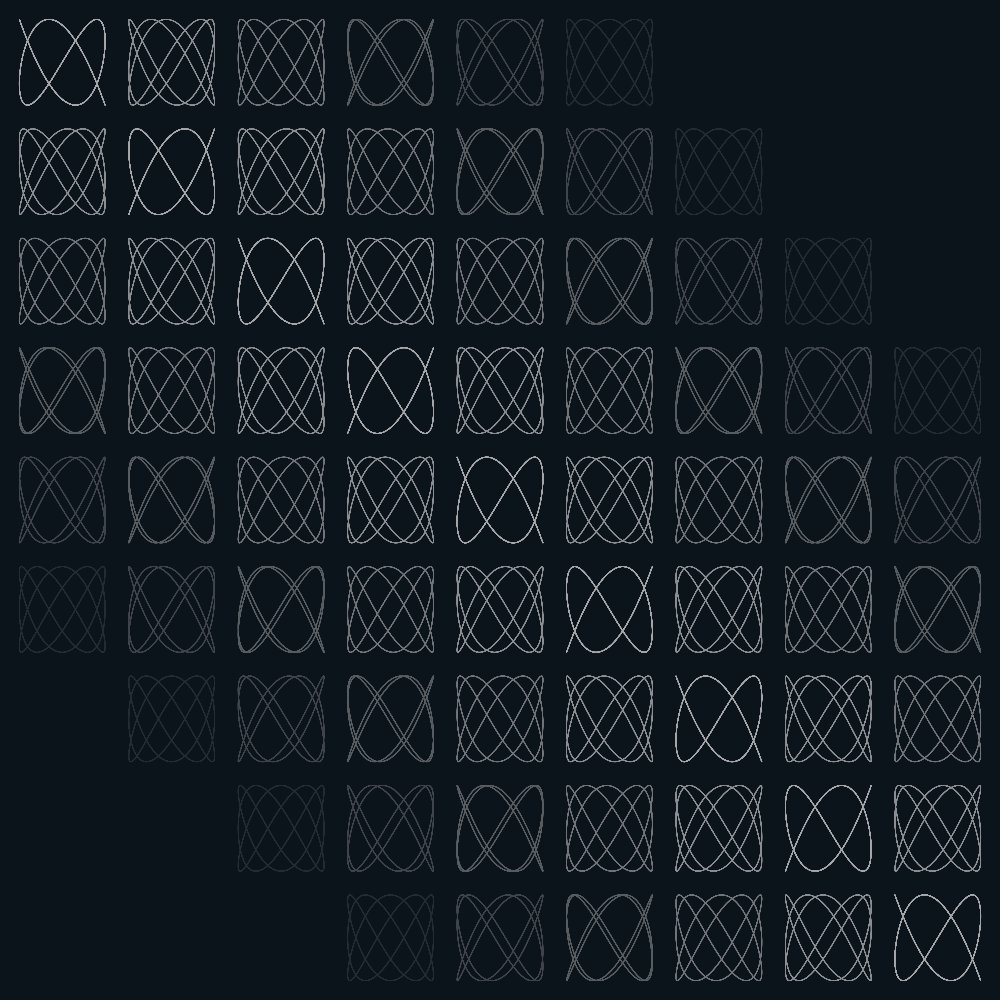

In [7]:
BG_COLOUR = "#0b131b"
FG_COLOUR = "#f0f0f0"

# Square central plot, two thin subplots on top and right
grid_size = 9
nrows, ncols = grid_size, grid_size
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(10, 10),
)

for n, ax in enumerate(axes.flatten()):
    ax = blank_ax(ax)

    # Set colour
    ax.set_facecolor(BG_COLOUR)

    delta = n * np.pi / 10
    lissajous = Lissajous(3, 5, delta)

    x, y = lissajous.value()
    # Get distance from central diagonal on 10 x 10 grid
    distance = abs(n % ncols - n // ncols)
    alpha = (distance + 3) / ncols
    if alpha > 1:
        alpha = 1
    ax.plot(x, y, color=FG_COLOUR, linewidth=0.5, alpha=1 - alpha)

plt.tight_layout()

fig.patch.set_facecolor(BG_COLOUR)
fig.savefig("img/celtic_office.png", dpi=150)

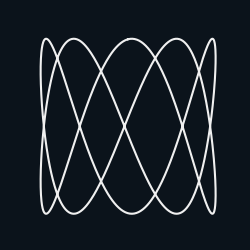

In [8]:
%matplotlib ipympl
import matplotlib.animation as animation


FRAMES = 60
INTERVAL = 16

fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax = blank_ax(ax)
fig.patch.set_facecolor(BG_COLOUR)
ax.set_facecolor(BG_COLOUR)

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect("equal", adjustable="box")

# Use the class implementation directly so the animation matches the same math.
t = np.linspace(0, 2, 1000)
start_delta = np.pi / 2
lissajous = Lissajous(a=2, b=5, delta=start_delta, t=t)
x0, y0 = lissajous.value()

line = ax.plot(x0, y0, color=FG_COLOUR, linewidth=1.5)[0]


def calulate_delta(frame):
    return start_delta + (2 * np.pi * frame / FRAMES)

def init():
    x, y = lissajous.value()
    line.set_data(x, y)
    return (line,)


def animate(frame):
    # Animate phase only; with a=b=1 this stays an ellipse (or line at 0, pi).
    delta = calulate_delta(frame)
    lissajous.delta = delta
    lissajous.wave2.phase = delta
    x, y = lissajous.value()
    line.set_data(x, y)
    return (line,)


anim = animation.FuncAnimation(
    fig,
    animate,
    init_func=init,
    frames=FRAMES,
    interval=INTERVAL,
    repeat=True,
 )

writer = animation.PillowWriter(fps=15,
                                metadata=dict(artist='Ian G'),
                                bitrate=1800)
anim.save('img/animation.gif', writer=writer, )
# plt.show()